In [ ]:
!pip install numpy==2.2.0
!pip install panda==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pdiddy

## Load the data
The dataset we will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.

In [9]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv'
df = pdiddy.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
167,2014,CADILLAC,CTS SEDAN AWD,MID-SIZE,3.6,6,AS6,X,13.1,9.0,11.3,25,260
273,2014,CHEVROLET,TRAX AWD,SUV - SMALL,1.4,4,AS6,X,10.0,7.8,9.0,31,207
882,2014,PORSCHE,911 TURBO,MINICOMPACT,3.8,6,AM7,Z,13.7,9.6,11.9,24,274
409,2014,FORD,FUSION,MID-SIZE,1.5,4,AS6,X,10.1,6.6,8.5,33,196
982,2014,TOYOTA,HIGHLANDER,SUV - SMALL,2.7,4,AS6,X,11.7,8.6,10.3,27,237


## Understand the data

### `FuelConsumption.csv`:
We will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

We will create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature.

### Explore the data
First, We consider a statistical summary of the data.

In [10]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.

#### Select features
We will select a few features that might be indicative of CO2 emission to explore more.

In [11]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
1064,3.0,6,11.8,271
915,3.6,6,17.8,285
120,4.4,8,14.7,338
1029,2.0,4,9.6,221
1054,3.6,6,12.2,281
336,1.4,4,7.8,179
788,1.6,4,8.7,200
32,3.0,6,8.4,227
220,5.3,8,21.5,344


#### Visualize features
Consider the histograms for each of these features.

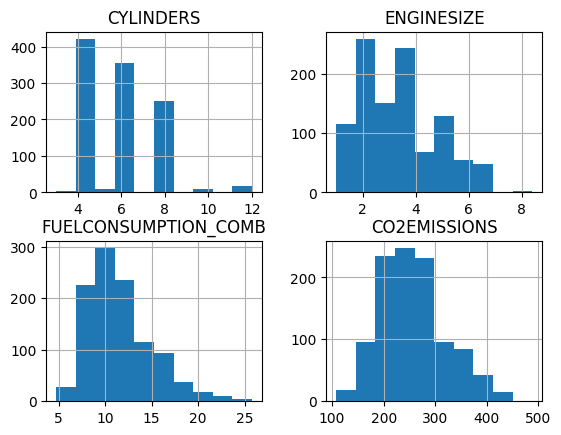

In [15]:
vis = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
vis.hist()
plt.show()